In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings


In [2]:
df = pd.read_csv('/kaggle/input/tertiary-mushroom-1-million-more-mushrooms/test.csv')
df.head()

,class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0,p;0.78;x;g;e;f;a;;p;4.31;1.05;;s;k;;;f;f;;d;s
1,p;4.6;x;e;e;f;a;;n;7.41;9.73;;;y;;w;t;z;;d;a
2,p;5.71;f;;y;f;s;d;y;7.58;13.89;;i;y;;;f;f;;d;a
3,e;1.41;c;g;n;f;a;;g;4.86;1.26;;;g;;;f;f;;l;a
4,e;11.13;f;e;b;f;;c;b;5.34;21.61;;;w;;;t;f;;d;a


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519000 entries, 0 to 518999
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                             Non-Null Count   Dtype 
---  ------                                                                                                                                                                                                                                             --------------   ----- 
 0   class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season  519000 non-null  object
dtypes: object(1)
memory usage: 4.0+ MB


In [7]:
df.dtypes

class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season    object
dtype: object

In [8]:
df.columns

Index(['class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season'], dtype='object')

In [11]:
df.describe().T

,count,unique,top,freq
class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season,519000,514529,p;2.94;o;l;g;f;f;f;f;0.0;0.0;f;f;f;;;f;f;;d;s,17


In [12]:
df.skew

<bound method DataFrame.skew of        class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0           p;0.78;x;g;e;f;a;;p;4.31;1.05;;s;k;;;f;f;;d;s                                                                                                                                                                                               
1            p;4.6;x;e;e;f;a;;n;7.41;9.73;;;y;;w;t;z;;d;a                                                                                                                                                                                               
2          p;5.71;f;;y;f;s;d;y;7.58;13.89;;i;y;;;f;f;;d;a                                                                                                                                                                    

In [13]:
df.kurt

<bound method DataFrame.kurt of        class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0           p;0.78;x;g;e;f;a;;p;4.31;1.05;;s;k;;;f;f;;d;s                                                                                                                                                                                               
1            p;4.6;x;e;e;f;a;;n;7.41;9.73;;;y;;w;t;z;;d;a                                                                                                                                                                                               
2          p;5.71;f;;y;f;s;d;y;7.58;13.89;;i;y;;;f;f;;d;a                                                                                                                                                                    

In [15]:
df.corr

<bound method DataFrame.corr of        class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0           p;0.78;x;g;e;f;a;;p;4.31;1.05;;s;k;;;f;f;;d;s                                                                                                                                                                                               
1            p;4.6;x;e;e;f;a;;n;7.41;9.73;;;y;;w;t;z;;d;a                                                                                                                                                                                               
2          p;5.71;f;;y;f;s;d;y;7.58;13.89;;i;y;;;f;f;;d;a                                                                                                                                                                    

In [16]:
df.shape

(519000, 1)

In [17]:
cat_cols = df.select_dtypes(include='object')

In [19]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season





In [20]:
num_cols = df.select_dtypes(include='number')

In [21]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

<Axes: >

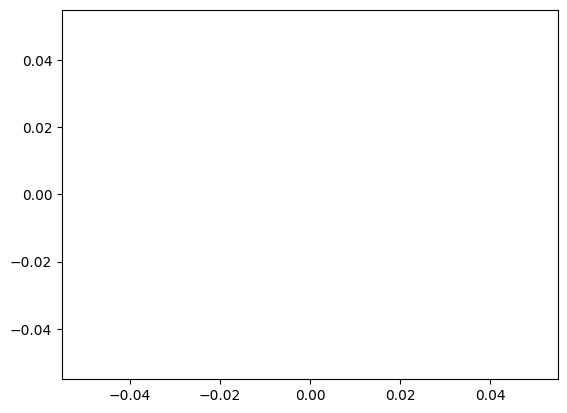

In [23]:
sns.scatterplot(df)

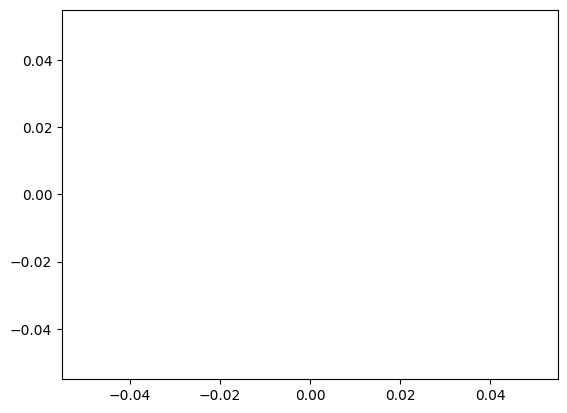

In [35]:
x = 1
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=df)
    print('\n')
    plt.show()

In [40]:
df.head()

,class;cap-diameter;cap-shape;cap-surface;cap-color;does-bruise-or-bleed;gill-attachment;gill-spacing;gill-color;stem-height;stem-width;stem-root;stem-surface;stem-color;veil-type;veil-color;has-ring;ring-type;spore-print-color;habitat;season
0,p;0.78;x;g;e;f;a;;p;4.31;1.05;;s;k;;;f;f;;d;s
1,p;4.6;x;e;e;f;a;;n;7.41;9.73;;;y;;w;t;z;;d;a
2,p;5.71;f;;y;f;s;d;y;7.58;13.89;;i;y;;;f;f;;d;a
3,e;1.41;c;g;n;f;a;;g;4.86;1.26;;;g;;;f;f;;l;a
4,e;11.13;f;e;b;f;;c;b;5.34;21.61;;;w;;;t;f;;d;a


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


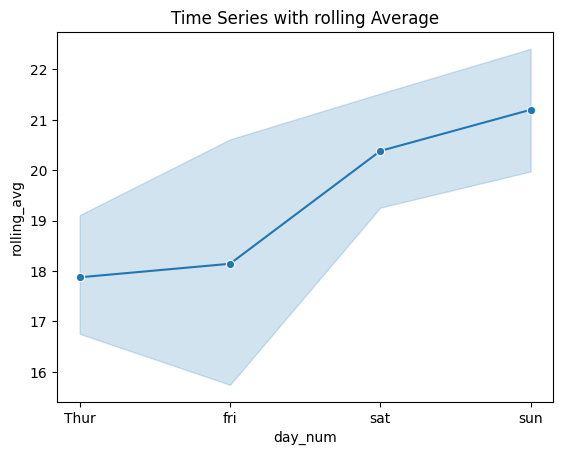

In [44]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill']. rolling(window=3).mean()

sns.lineplot(x='day_num',y='rolling_avg', data=df_tips, marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','fri','sat','sun'])
plt.title("Time Series with rolling Average")
plt.show()